In [65]:
#pip install opencv-python

In [10]:
import os
import re
import pandas as pd
import cv2 # opencv library
import numpy as np
from os.path import isfile, join
import matplotlib.pyplot as plt
from datetime import datetime


In [126]:
import urllib.request
image_name = "./images/grca_webcam " + str(datetime.now())[:13] + ".jpg"
urllib.request.urlretrieve("https://www.nps.gov/webcams-grca/camera0.jpg", image_name)


('./images/grca_webcam 2023-01-24 18.jpg',
 <http.client.HTTPMessage at 0x208aa04daf0>)

In [135]:
col_frames = os.listdir('./images/')
col_frames

['camera0 (1).jpg',
 'camera0 (2).jpg',
 'camera0.jpg',
 'GRCA webcam no vehicles 11282022.jpg',
 'grca_webcam 2023-01-24 18.jpg',
 'grca_webcam no vehicles snow 2023-01-24 17.jpg',
 'grca_webcam.jpg',
 'webcam_output_11142022.jpg',
 'webcam_output_11212022.jpg',
 'webcam_output_11212022_1.jpg']

In [136]:
col_images = []

In [137]:
for i in col_frames:
    # read the frames
    img = cv2.imread('./images/'+i)
    # append the frames to the list
    col_images.append(img)

In [138]:
len(col_images)

10

In [140]:
analysis_image.shape

(960, 1296, 3)

0.375
1.2547368421052632


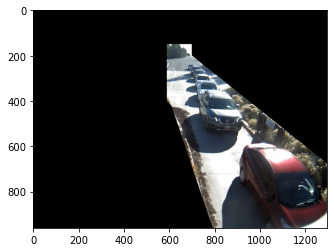

In [141]:
y = 590
analysis_image = col_images[1]
analysis_image[0 : 960, 0 : y] = (0, 0, 0)
analysis_image[0 : 150, 0 : 1296] = (0, 0, 0)

inc_amount = (800-y)/560
print(inc_amount)
for x in range(400,961):
    analysis_image[x : 960, 0 : int(y)] = (0, 0, 0)
    if x<420:
        y = y+1
    elif x ==420:
        y = y+1
        inc_amount = (800-y)/560
    else:
        y = y+inc_amount


y = 700
inc_amount = (1296-700)/(675-200)
print(inc_amount)
for x in range(200,675):
    analysis_image[0 : x, int(y) : 1296] = (0, 0, 0)
    y = y+inc_amount

    
plt.imshow(cv2.cvtColor(analysis_image, cv2.COLOR_BGR2RGB))
plt.show()


In [142]:
def crop_lane_three(analysis_image):
    y = 590
    analysis_image[0 : 960, 0 : y] = (0, 0, 0)
    analysis_image[0 : 180, 0 : 1296] = (0, 0, 0)

    inc_amount = (800-y)/560
    print(inc_amount)
    for x in range(400,961):
        analysis_image[x : 960, 0 : int(y)] = (0, 0, 0)
        if x<420:
            y = y+1
        elif x ==420:
            y = y+1
            inc_amount = (800-y)/560
        else:
            y = y+inc_amount


    y = 700
    inc_amount = (1296-700)/(675-200)
    print(inc_amount)
    for x in range(200,675):
        analysis_image[0 : x, int(y) : 1296] = (0, 0, 0)
        y = y+inc_amount

    return analysis_image


In [143]:
def vehicle_detection(image, base_nocars): 
    print(col_frames[image])
    base_nocars_img = cv2.imread('./images/'+col_frames[base_nocars])
    analysis_img  = cv2.imread('./images/'+col_frames[image])
    
  #  print("Base Image")
   # plt.imshow(cv2.cvtColor(base_nocars_img, cv2.COLOR_BGR2RGB))
   # plt.show()

  #  print("Image to Analyze")
  #  plt.imshow(cv2.cvtColor(analysis_img, cv2.COLOR_BGR2RGB))
 #   plt.show()

    base_nocars_img = crop_lane_three(base_nocars_img)
    analysis_img = crop_lane_three(analysis_img)


    grayA = cv2.cvtColor(base_nocars_img, cv2.COLOR_BGR2GRAY)
    grayB = cv2.cvtColor(analysis_img, cv2.COLOR_BGR2GRAY)
    


 #   print("Differencing")
    # plot the image after frame differencing
  #  plt.imshow(cv2.absdiff(grayB, grayA), cmap = 'gray')
 #   plt.show()

    diff_image = cv2.absdiff(grayB, grayA)

    # perform image thresholding
    ret, thresh = cv2.threshold(diff_image, 60, 255, cv2.THRESH_BINARY)

 #   plt.imshow(thresh, cmap = 'gray')
 #   plt.show()

    # apply image dilation
    kernel = np.ones((3,3),np.uint8)
    kernel

    dilated = cv2.dilate(thresh,kernel,iterations = 4)

    # original image
    # -1 loads as-is so if it will be 3 or 4 channel as the original
    image = thresh
    # mask defaulting to black for 3-channel and transparent for 4-channel

    contours, hierarchy = cv2.findContours(thresh.copy(),cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)

    valid_cntrs = []

    for i,cntr in enumerate(contours):
        x,y,w,h = cv2.boundingRect(cntr)
        area = cv2.contourArea(cntr)         
        if area > 200:  
            valid_cntrs.append(cntr)

    # count of discovered contours        

    dmy = analysis_img.copy()

    print("Contours Drawn:")
    cv2.drawContours(dmy, valid_cntrs, -1, (127,200,0), 2)

    print("Number of Contours: ", len(valid_cntrs))
    if len(valid_cntrs) >0:
        all_contours = np.concatenate(valid_cntrs, axis=0)
        print("Above threshold, vehicles present")
        min_arg = all_contours[all_contours[:,:,1].argmin(axis = 0)][:,:,1].astype(int)
        #print(type(min_arg[[0]]))
        #print(min_arg[[0]])
        min_arg_df = pd.DataFrame(min_arg, columns = ['value']) 
        print("Line starts at y pixel:",min_arg_df.iloc[0]['value'])
        cv2.line(dmy, (0, min_arg_df.iloc[0]['value']),(1200,min_arg_df.iloc[0]['value']),(255, 255, 255))
    else: 
        print("Not above threshold. No Vehicle.")
        
    plt.imshow(dmy)
    plt.show()


In [144]:
col_frames

['camera0 (1).jpg',
 'camera0 (2).jpg',
 'camera0.jpg',
 'GRCA webcam no vehicles 11282022.jpg',
 'grca_webcam 2023-01-24 18.jpg',
 'grca_webcam no vehicles snow 2023-01-24 17.jpg',
 'grca_webcam.jpg',
 'webcam_output_11142022.jpg',
 'webcam_output_11212022.jpg',
 'webcam_output_11212022_1.jpg']

webcam_output_11212022_1.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  27
Above threshold, vehicles present
Line starts at y pixel: 180


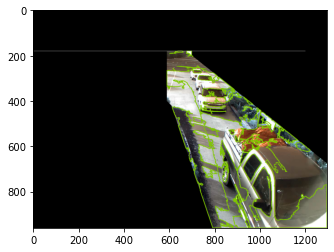

camera0 (1).jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  21
Above threshold, vehicles present
Line starts at y pixel: 180


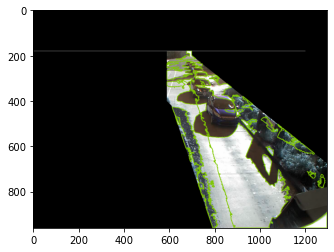

camera0 (2).jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  20
Above threshold, vehicles present
Line starts at y pixel: 180


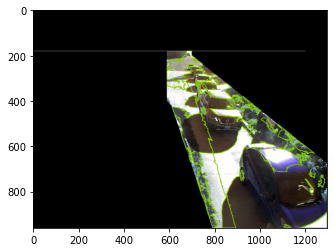

camera0.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  19
Above threshold, vehicles present
Line starts at y pixel: 180


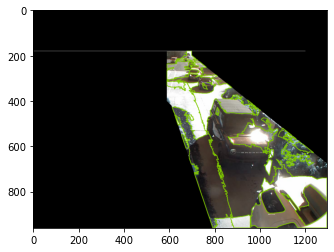

GRCA webcam no vehicles 11282022.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  20
Above threshold, vehicles present
Line starts at y pixel: 180


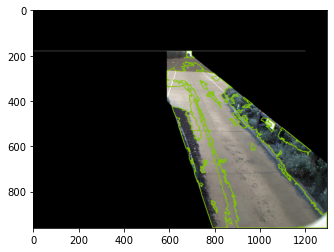

grca_webcam 2023-01-24 18.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  19
Above threshold, vehicles present
Line starts at y pixel: 191


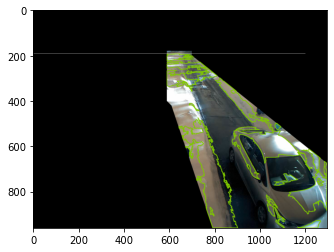

grca_webcam no vehicles snow 2023-01-24 17.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  0
Not above threshold. No Vehicle.


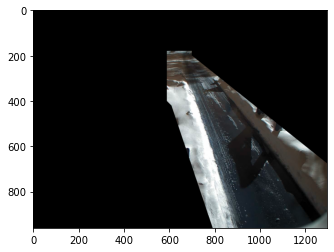

grca_webcam.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  7
Above threshold, vehicles present
Line starts at y pixel: 539


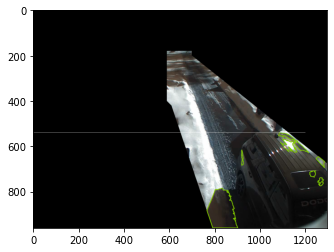

webcam_output_11142022.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  19
Above threshold, vehicles present
Line starts at y pixel: 180


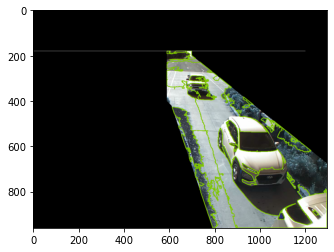

webcam_output_11212022.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  30
Above threshold, vehicles present
Line starts at y pixel: 180


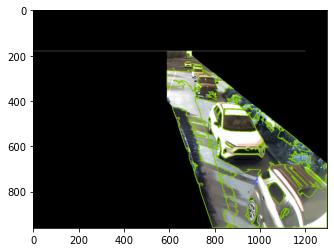

webcam_output_11212022_1.jpg
0.375
1.2547368421052632
0.375
1.2547368421052632
Contours Drawn:
Number of Contours:  27
Above threshold, vehicles present
Line starts at y pixel: 180


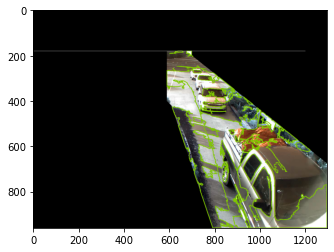

In [146]:
# convert the frames to grayscale
#to_analyze = 4
base_nocars = 5

for x in range(-1,len(col_frames)):
    vehicle_detection(x, base_nocars)

In [21]:
to_analyze=2
base_nocars = 3

In [100]:
str(datetime.now())[:13]

'2023-01-24 17'

In [102]:
from datetime import date
image_name = "./images/grca_webcam " + str(datetime.now())[:13] + ".jpg"
print(image_name)

./images/grca_webcam 2023-01-24 17.jpg


('./images/grca_webcam.jpg', <http.client.HTTPMessage at 0x208afc96d60>)